# **Load Dataset**

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/household_power_consumption.txt', sep=';', low_memory=False)

In [ ]:
data_before = data.copy()

In [ ]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 9 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Date                   object 
 1   Time                   object 
 2   Global_active_power    object 
 3   Global_reactive_power  object 
 4   Voltage                object 
 5   Global_intensity       object 
 6   Sub_metering_1         object 
 7   Sub_metering_2         object 
 8   Sub_metering_3         float64
dtypes: float64(1), object(8)
memory usage: 142.5+ MB
None


# **Preprocessing**

## **Missing Value**

In [ ]:
print("Informasi Data Awal:")
print(data.info())
print(data.head())

Informasi Data Awal:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 9 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Date                   object 
 1   Time                   object 
 2   Global_active_power    object 
 3   Global_reactive_power  object 
 4   Voltage                object 
 5   Global_intensity       object 
 6   Sub_metering_1         object 
 7   Sub_metering_2         object 
 8   Sub_metering_3         float64
dtypes: float64(1), object(8)
memory usage: 142.5+ MB
None
         Date      Time Global_active_power Global_reactive_power  Voltage  \
0  16/12/2006  17:24:00               4.216                 0.418  234.840   
1  16/12/2006  17:25:00               5.360                 0.436  233.630   
2  16/12/2006  17:26:00               5.374                 0.498  233.290   
3  16/12/2006  17:27:00               5.388                 0.502  233.740   
4  16/12/2006  17:28:0

In [ ]:
# 3. Mengonversi kolom Date dan Time menjadi datetime
data['Datetime'] = pd.to_datetime(data['Date'] + ' ' + data['Time'], format='%d/%m/%Y %H:%M:%S')
data.drop(['Date', 'Time'], axis=1, inplace=True)

In [ ]:
# Mengonversi kolom numerik dari object ke float
numeric_columns = ['Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2']
for col in numeric_columns:
    data[col] = pd.to_numeric(data[col], errors='coerce')


In [ ]:
print("Informasi Data Konversi:")
print(data.info())
print(data.head())

Informasi Data Konversi:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 8 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   Global_active_power    float64       
 1   Global_reactive_power  float64       
 2   Voltage                float64       
 3   Global_intensity       float64       
 4   Sub_metering_1         float64       
 5   Sub_metering_2         float64       
 6   Sub_metering_3         float64       
 7   Datetime               datetime64[ns]
dtypes: datetime64[ns](1), float64(7)
memory usage: 126.7 MB
None
   Global_active_power  Global_reactive_power  Voltage  Global_intensity  \
0                4.216                  0.418   234.84              18.4   
1                5.360                  0.436   233.63              23.0   
2                5.374                  0.498   233.29              23.0   
3                5.388                  0.502   233.74         

In [ ]:
missing_values = data.isnull().sum()
print("Missing values per column:")
print(missing_values)

Missing values per column:
Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
Datetime                     0
dtype: int64


In [ ]:
print(type(data))

<class 'pandas.core.frame.DataFrame'>


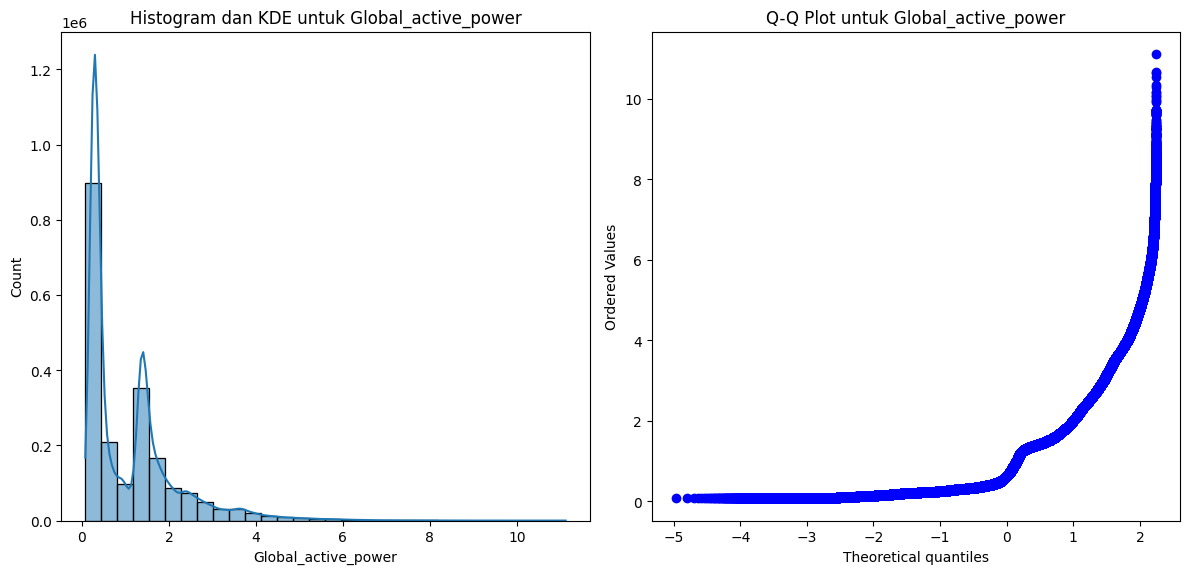

Uji Shapiro-Wilk untuk Global_active_power: Statistik = nan, p-value = nan
Global_active_power tidak terdistribusi normal (menolak H0)



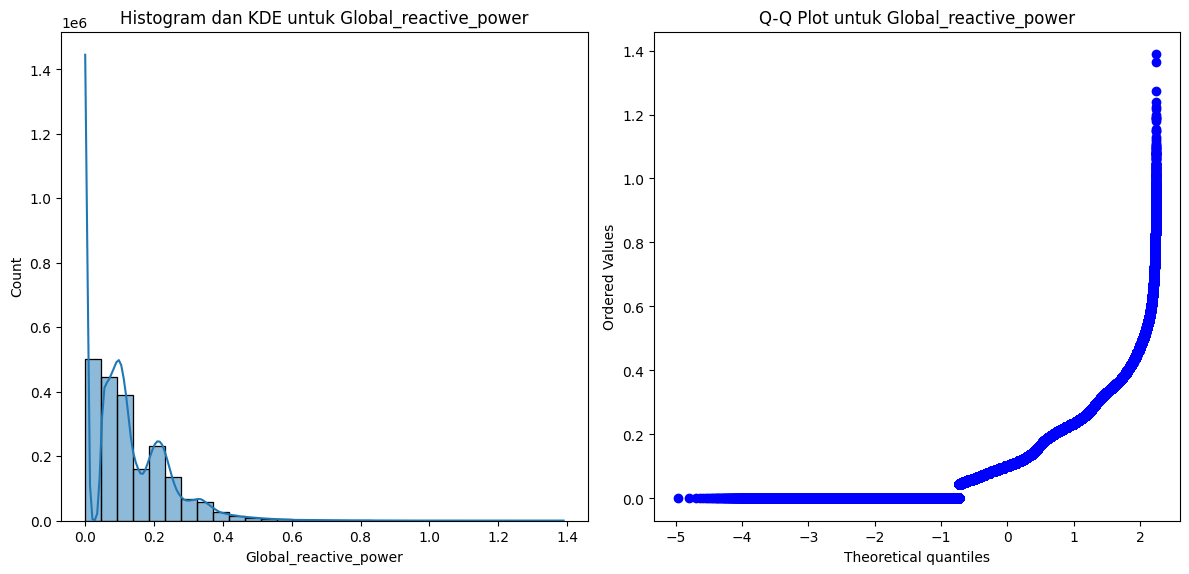

Uji Shapiro-Wilk untuk Global_reactive_power: Statistik = nan, p-value = nan
Global_reactive_power tidak terdistribusi normal (menolak H0)



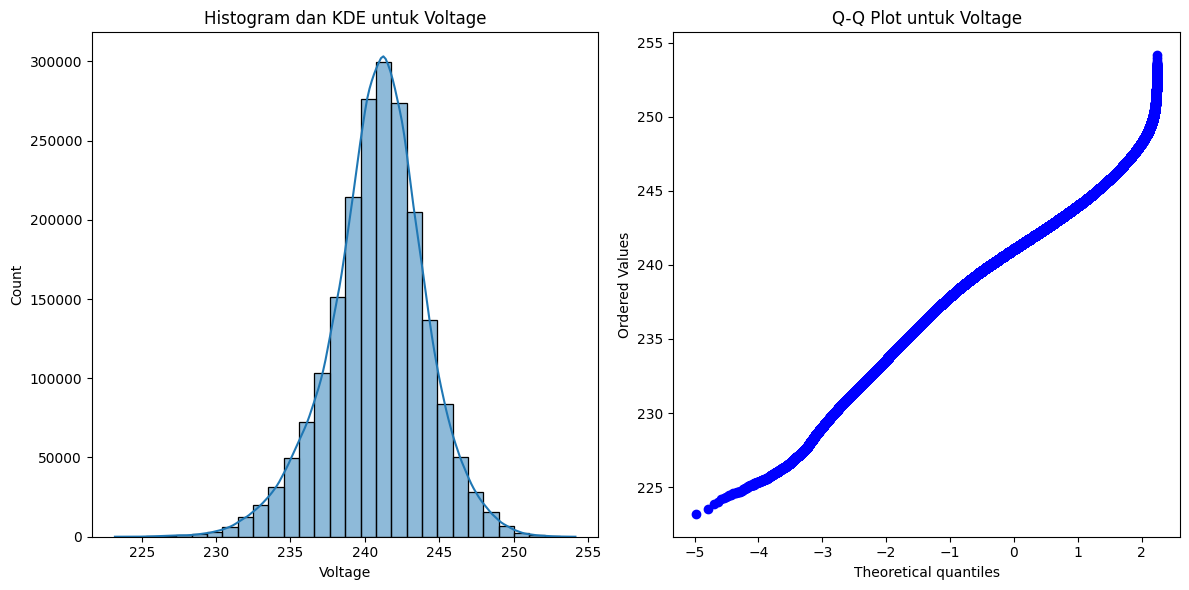

Uji Shapiro-Wilk untuk Voltage: Statistik = nan, p-value = nan
Voltage tidak terdistribusi normal (menolak H0)



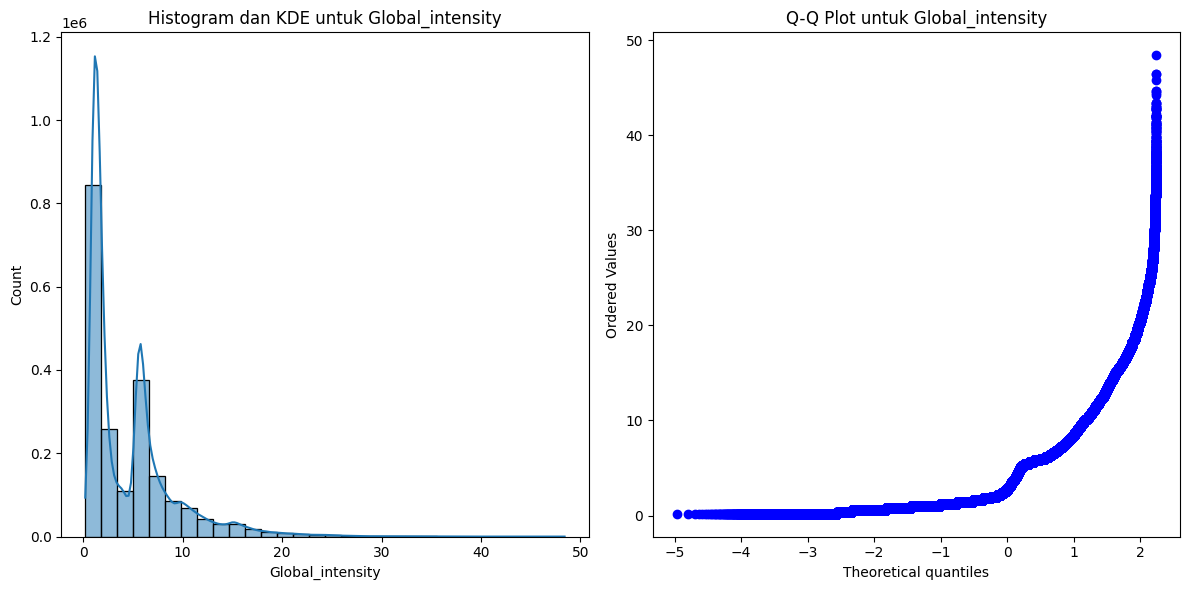

Uji Shapiro-Wilk untuk Global_intensity: Statistik = nan, p-value = nan
Global_intensity tidak terdistribusi normal (menolak H0)



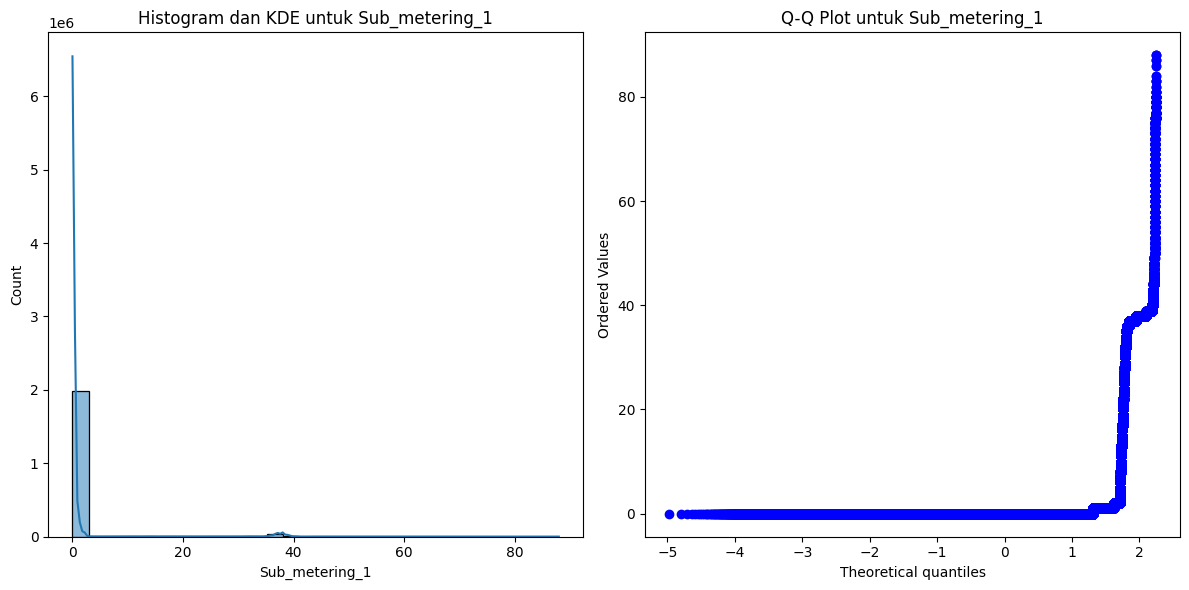

Uji Shapiro-Wilk untuk Sub_metering_1: Statistik = nan, p-value = nan
Sub_metering_1 tidak terdistribusi normal (menolak H0)



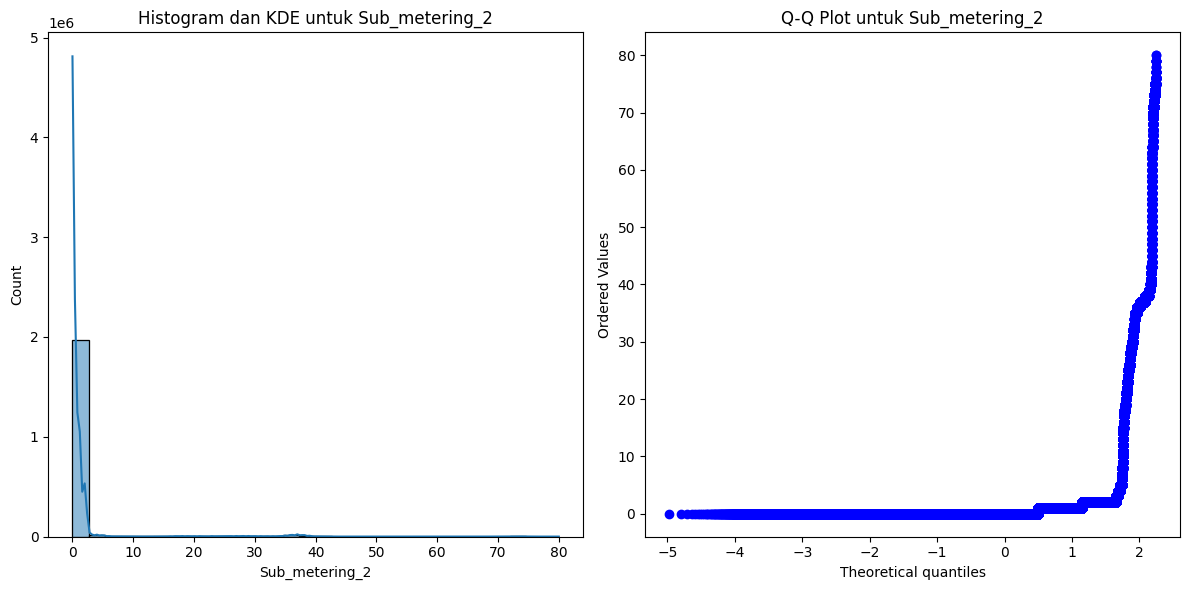

Uji Shapiro-Wilk untuk Sub_metering_2: Statistik = nan, p-value = nan
Sub_metering_2 tidak terdistribusi normal (menolak H0)



In [ ]:
# Memeriksa distribusi normal dari setiap kolom
for column in numeric_columns:
    plt.figure(figsize=(12, 6))

    # Histogram dan KDE
    plt.subplot(1, 2, 1)
    sns.histplot(data[column], bins=30, kde=True)
    plt.title(f'Histogram dan KDE untuk {column}')

    # Q-Q Plot
    plt.subplot(1, 2, 2)
    stats.probplot(data[column], dist="norm", plot=plt)
    plt.title(f'Q-Q Plot untuk {column}')
    plt.tight_layout()
    plt.show()

    # Uji Shapiro-Wilk
    shapiro_test = stats.shapiro(data[column])
    print(f'Uji Shapiro-Wilk untuk {column}: Statistik = {shapiro_test.statistic}, p-value = {shapiro_test.pvalue}')

    # Interpretasi hasil uji
    alpha = 0.05
    if shapiro_test.pvalue > alpha:
        print(f'{column} terdistribusi normal (gagal menolak H0)\n')
    else:
        print(f'{column} tidak terdistribusi normal (menolak H0)\n')

In [ ]:
data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/household_power_consumption.txt', sep=';', low_memory=False)
data_before = data.copy()

# Memeriksa missing values sebelum penanganan
missing_values_before = data_before.isnull().sum()
print("Missing values per column sebelum penanganan:")
print(missing_values_before)

# Mengonversi kolom Date dan Time menjadi datetime
data['Datetime'] = pd.to_datetime(data['Date'] + ' ' + data['Time'], format='%d/%m/%Y %H:%M:%S')
data.drop(['Date', 'Time'], axis=1, inplace=True)

# Mengonversi kolom numerik dari object ke float
numeric_columns = ['Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2']
for col in numeric_columns:
    data[col] = pd.to_numeric(data[col], errors='coerce')

# Memeriksa missing values setelah konversi
missing_values_after_conversion = data.isnull().sum()
print("\nMissing values per column setelah konversi:")
print(missing_values_after_conversion)

# Menangani missing values
data.dropna(inplace=True)
# Mengisi missing values dengan median tanpa menggunakan inplace=True
for col in numeric_columns:
    data[col] = data[col].fillna(data[col].median())

# Memeriksa missing values setelah penanganan
missing_values_after = data.isnull().sum()
print("\nMissing values per column setelah penanganan:")
print(missing_values_after)

# sebelum penanganan missing values
print("\nData sebelum penanganan missing values:")
print(data_before.head())
print("\nInformasi Data Sebelum:")
print(data_before.info())

# setelah penanganan missing values
print("\nData setelah penanganan missing values:")
print(data.head())
print("\nInformasi Data Setelah:")
print(data.info())

Missing values per column sebelum penanganan:
Date                         0
Time                         0
Global_active_power          0
Global_reactive_power        0
Voltage                      0
Global_intensity             0
Sub_metering_1               0
Sub_metering_2               0
Sub_metering_3           25979
dtype: int64

Missing values per column setelah konversi:
Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
Datetime                     0
dtype: int64

Missing values per column setelah penanganan:
Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
Datetime                 0
dtype: int64

Data sebelum penanganan missing values:
         Date      Time Global_active_p

In [ ]:
# Memeriksa jumlah baris setelah penanganan
jumlah_baris_after = data.shape[0]
print(f"Jumlah baris setelah penanganan: {jumlah_baris_after}")


Jumlah baris setelah penanganan: 2049280


## **Outliers**

Jumlah outlier: 94907


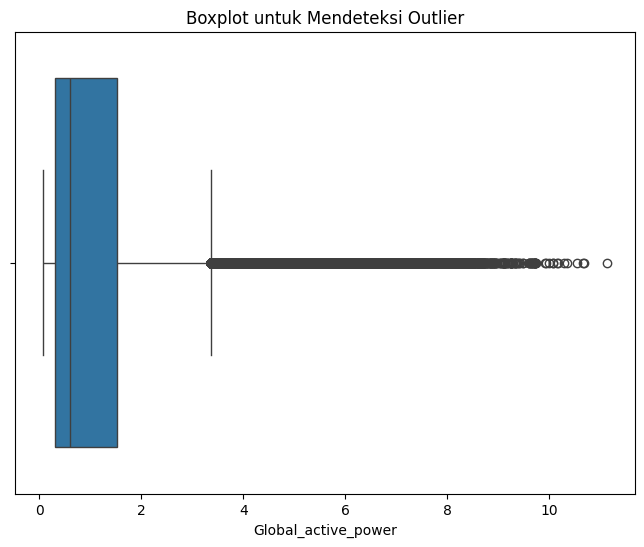

In [ ]:
Q1 = data['Global_active_power'].quantile(0.25)
Q3 = data['Global_active_power'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = data[(data['Global_active_power'] < lower_bound) | (data['Global_active_power'] > upper_bound)]
print(f'Jumlah outlier: {outliers.shape[0]}')

# Visualisasi dengan Boxplot
plt.figure(figsize=(8, 6))
sns.boxplot(x=data['Global_active_power'])
plt.title('Boxplot untuk Mendeteksi Outlier')
plt.show()

Jumlah outlier: 40420


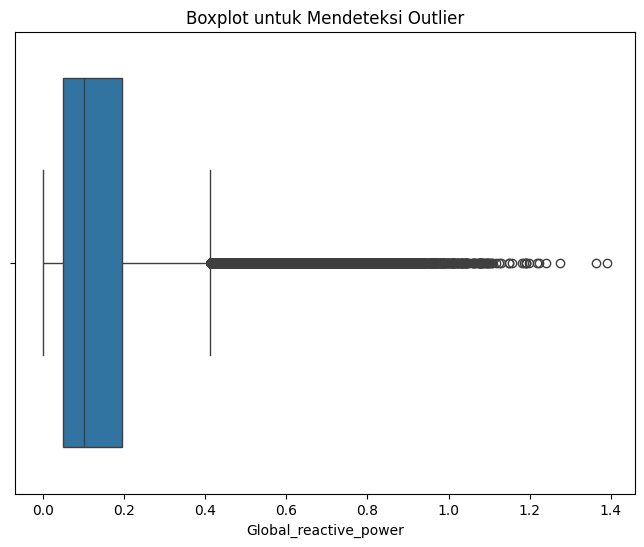

In [ ]:
Q1 = data['Global_reactive_power'].quantile(0.25)
Q3 = data['Global_reactive_power'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = data[(data['Global_reactive_power'] < lower_bound) | (data['Global_reactive_power'] > upper_bound)]
print(f'Jumlah outlier: {outliers.shape[0]}')

# Visualisasi dengan Boxplot
plt.figure(figsize=(8, 6))
sns.boxplot(x=data['Global_reactive_power'])
plt.title('Boxplot untuk Mendeteksi Outlier')
plt.show()

Jumlah outlier: 51067


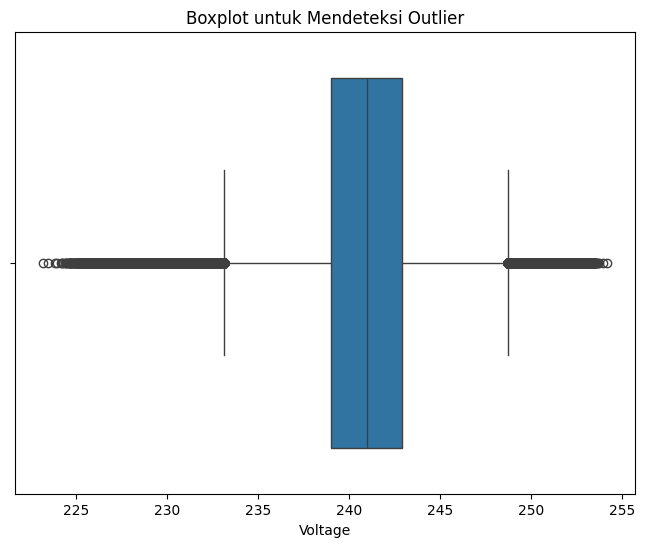

In [ ]:
Q1 = data['Voltage'].quantile(0.25)
Q3 = data['Voltage'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = data[(data['Voltage'] < lower_bound) | (data['Voltage'] > upper_bound)]
print(f'Jumlah outlier: {outliers.shape[0]}')

# Visualisasi dengan Boxplot
plt.figure(figsize=(8, 6))
sns.boxplot(x=data['Voltage'])
plt.title('Boxplot untuk Mendeteksi Outlier')
plt.show()

Jumlah outlier: 100961


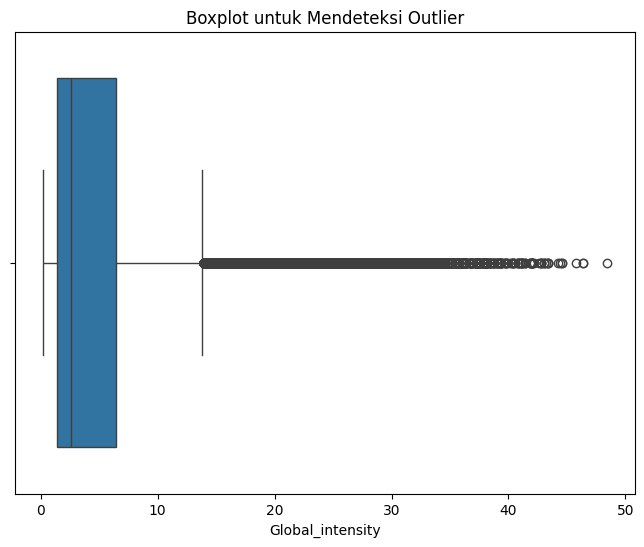

In [ ]:
Q1 = data['Global_intensity'].quantile(0.25)
Q3 = data['Global_intensity'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = data[(data['Global_intensity'] < lower_bound) | (data['Global_intensity'] > upper_bound)]
print(f'Jumlah outlier: {outliers.shape[0]}')

# Visualisasi dengan Boxplot
plt.figure(figsize=(8, 6))
sns.boxplot(x=data['Global_intensity'])
plt.title('Boxplot untuk Mendeteksi Outlier')
plt.show()

Streaming output truncated to the last 5000 lines.
Index 1849295: Kesalahan input yang mungkin terjadi
Index 1849296: Kesalahan input yang mungkin terjadi
Index 1849297: Kesalahan input yang mungkin terjadi
Index 1849298: Kesalahan input yang mungkin terjadi
Index 1849299: Kesalahan input yang mungkin terjadi
Index 1849987: Kesalahan input yang mungkin terjadi
Index 1849988: Kesalahan input yang mungkin terjadi
Index 1849989: Kesalahan input yang mungkin terjadi
Index 1849990: Kesalahan input yang mungkin terjadi
Index 1849991: Kesalahan input yang mungkin terjadi
Index 1849992: Kesalahan input yang mungkin terjadi
Index 1849996: Kesalahan input yang mungkin terjadi
Index 1850448: Kesalahan input yang mungkin terjadi
Index 1850449: Kesalahan input yang mungkin terjadi
Index 1850450: Kesalahan input yang mungkin terjadi
Index 1850451: Kesalahan input yang mungkin terjadi
Index 1850452: Kesalahan input yang mungkin terjadi
Index 1850453: Kesalahan input yang mungkin terjadi
Index 1850454

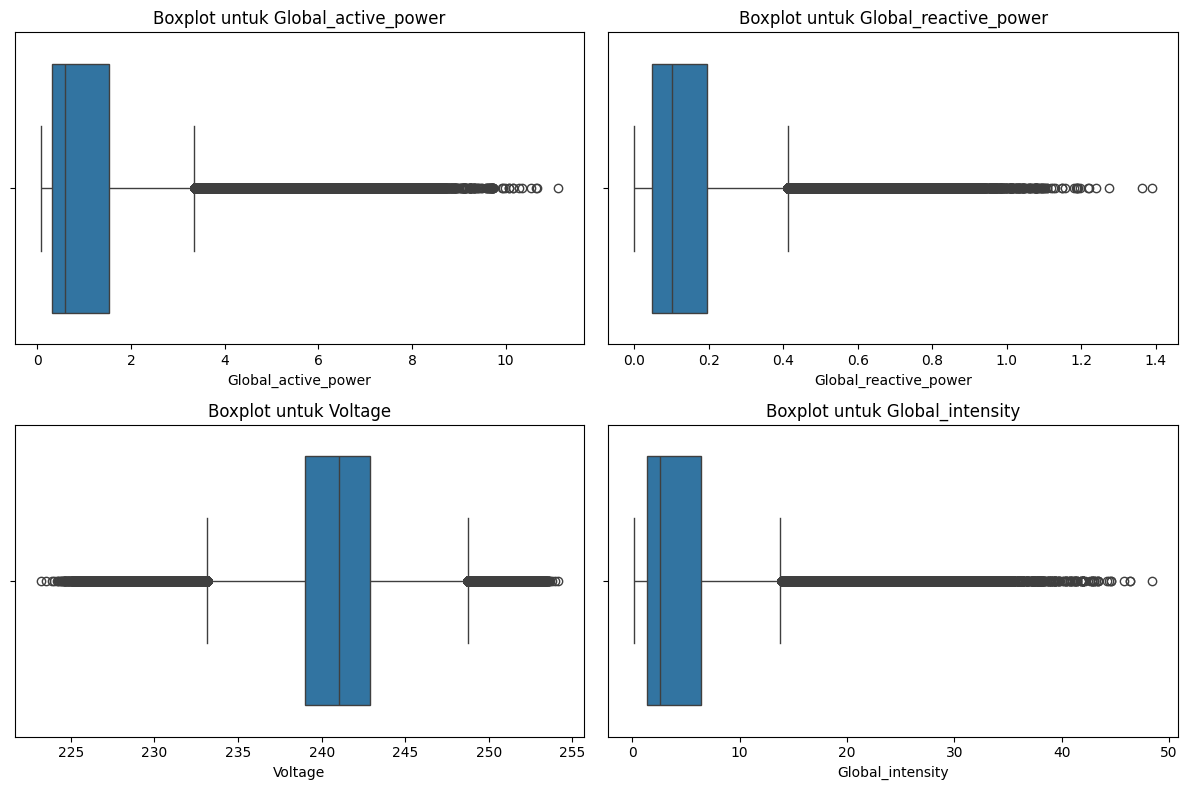

In [ ]:
# Fungsi untuk menghitung batas IQR
def calculate_iqr_bounds(column):
    Q1 = column.quantile(0.25)
    Q3 = column.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return lower_bound, upper_bound
columns_to_check = ['Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity']
bounds = {col: calculate_iqr_bounds(data[col]) for col in columns_to_check}
# Mengidentifikasi outlier
outlier_info = {}
for col in columns_to_check:
    lower_bound, upper_bound = bounds[col]
    outliers = data[(data[col] < lower_bound) | (data[col] > upper_bound)]
    outlier_info[col] = outliers
# Menampilkan informasi tentang outlier
for col, outliers in outlier_info.items():
    print(f"\nOutlier untuk kolom {col}:")
    print(outliers)
    # Analisis penyebab
    print("\nAnalisis Penyebab Outlier:")
    for index, row in outliers.iterrows():
        if row[col] < 0:
            print(f"Index {index}: Kesalahan pengukuran (nilai negatif)")
        elif row[col] > 1000:
            print(f"Index {index}: Nilai ekstrem yang mungkin valid")
        else:
            print(f"Index {index}: Kesalahan input yang mungkin terjadi")
plt.figure(figsize=(12, 8))
for i, col in enumerate(columns_to_check, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x=data[col])
    plt.title(f'Boxplot untuk {col}')
plt.tight_layout()
plt.show()

In [ ]:
# Menghitung batas IQR untuk setiap kolom
def calculate_iqr_bounds(column):
    Q1 = column.quantile(0.25)
    Q3 = column.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return lower_bound, upper_bound

columns_to_check = ['Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity']
bounds = {col: calculate_iqr_bounds(data[col]) for col in columns_to_check}

# Imputasi outlier dengan median
for col in columns_to_check:
    lower_bound, upper_bound = bounds[col]
    median_value = data[col].median()
    data[col] = np.where((data[col] < lower_bound) | (data[col] > upper_bound), median_value, data[col])

print("\nData setelah imputasi outlier:")
print(data[columns_to_check].describe())


Data setelah imputasi outlier:
       Global_active_power  Global_reactive_power       Voltage  \
count         2.049280e+06           2.049280e+06  2.049280e+06   
mean          9.202553e-01           1.156716e-01  2.409526e+02   
std           7.647145e-01           9.778630e-02  2.887348e+00   
min           7.600000e-02           0.000000e+00  2.331500e+02   
25%           3.080000e-01           4.800000e-02  2.391700e+02   
50%           6.020000e-01           1.000000e-01  2.410100e+02   
75%           1.436000e+00           1.840000e-01  2.428200e+02   
max           3.358000e+00           4.120000e-01  2.487300e+02   

       Global_intensity  
count      2.049280e+06  
mean       3.869655e+00  
std        3.136158e+00  
min        2.000000e-01  
25%        1.400000e+00  
50%        2.600000e+00  
75%        6.000000e+00  
max        1.380000e+01  


## **Normalisasi**

In [ ]:
columns_to_check = ['Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity']

if isinstance(data, pd.DataFrame) and all(col in data.columns for col in columns_to_check):
    bounds = {col: calculate_iqr_bounds(data[col]) for col in columns_to_check}

    scaler = MinMaxScaler()
    # Melakukan normalisasi pada kolom yang telah diimputasi
    data[columns_to_check] = scaler.fit_transform(data[columns_to_check])

    print("\nData setelah normalisasi:")
    print(data[columns_to_check].describe())
else:
    print("Data tidak valid atau kolom tidak ditemukan.")


Data setelah normalisasi:
       Global_active_power  Global_reactive_power       Voltage  \
count         2.049280e+06           2.049280e+06  2.049280e+06   
mean          2.572380e-01           2.807564e-01  5.008090e-01   
std           2.330026e-01           2.373454e-01  1.853240e-01   
min           0.000000e+00           0.000000e+00  0.000000e+00   
25%           7.068860e-02           1.165049e-01  3.863928e-01   
50%           1.602681e-01           2.427184e-01  5.044929e-01   
75%           4.143815e-01           4.466019e-01  6.206675e-01   
max           1.000000e+00           1.000000e+00  1.000000e+00   

       Global_intensity  
count      2.049280e+06  
mean       2.698276e-01  
std        2.305998e-01  
min        0.000000e+00  
25%        8.823529e-02  
50%        1.764706e-01  
75%        4.264706e-01  
max        1.000000e+00  


In [ ]:
# Menyimpan DataFrame yang telah diproses ke dalam file CSV
output_file_path = '/content/drive/MyDrive/Colab Notebooks/household_power_consumption_processed.csv'
data.to_csv(output_file_path, index=False)

print(f"Data telah disimpan ke {output_file_path}")

Data telah disimpan ke /content/drive/MyDrive/Colab Notebooks/household_power_consumption_processed.csv


In [ ]:
# Membaca DataFrame dari file CSV yang telah disimpan
loaded_data = pd.read_csv(output_file_path)

# Menampilkan informasi dan beberapa baris pertama dari data yang dimuat
print("Data yang dimuat dari CSV:")
print(loaded_data.info())
print(loaded_data.head())

Data yang dimuat dari CSV:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2049280 entries, 0 to 2049279
Data columns (total 8 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Global_active_power    float64
 1   Global_reactive_power  float64
 2   Voltage                float64
 3   Global_intensity       float64
 4   Sub_metering_1         float64
 5   Sub_metering_2         float64
 6   Sub_metering_3         float64
 7   Datetime               object 
dtypes: float64(7), object(1)
memory usage: 125.1+ MB
None
   Global_active_power  Global_reactive_power   Voltage  Global_intensity  \
0             0.160268               0.242718  0.108472          0.176471   
1             0.160268               0.242718  0.030809          0.176471   
2             0.160268               0.242718  0.008986          0.176471   
3             0.160268               0.242718  0.037869          0.176471   
4             0.160268               0.242718  0.162388  

## **Feature engineering**

### **Active Energy Consumed by Other Equipment**

In [ ]:
data = pd.DataFrame(data)

data['other_active_energy'] = (data['Global_active_power'] * 1000 / 60) - (
    data['Sub_metering_1'] + data['Sub_metering_2'] + data['Sub_metering_3']
)
print(data['other_active_energy'])

0         -15.328865
1         -14.328865
2         -16.328865
3         -15.328865
4         -15.328865
             ...    
2075254     4.418038
2075255     4.407881
2075256     4.377412
2075257     4.357099
2075258     4.346943
Name: other_active_energy, Length: 2049280, dtype: float64


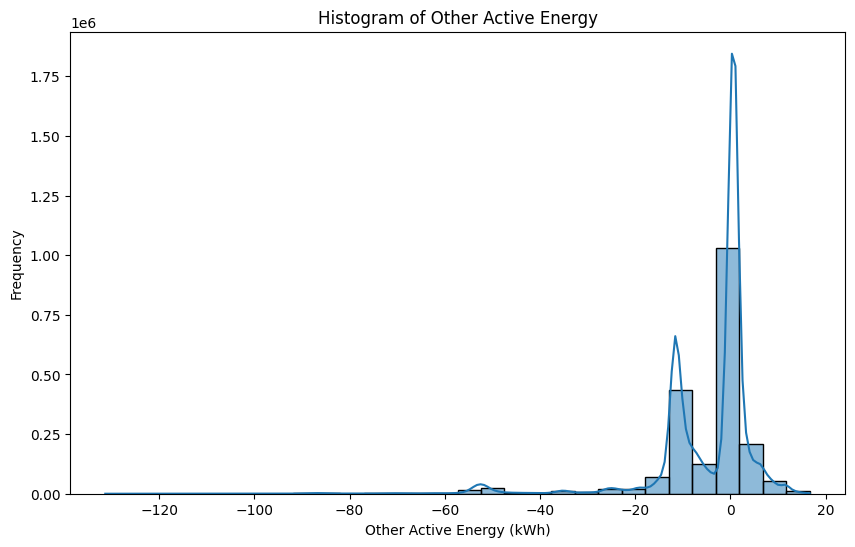

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(data['other_active_energy'], bins=30, kde=True)  # bins=30 untuk jumlah bin, kde=True untuk menambahkan garis distribusi
plt.title('Histogram of Other Active Energy')
plt.xlabel('Other Active Energy (kWh)')
plt.ylabel('Frequency')
plt.show()

### **Daily Energy Consumption**

In [ ]:
import pandas as pd

data = pd.DataFrame({
    'Global_active_power': [0.00, 0.25, 0.50, 0.75, 1.00],
    'Global_reactive_power': [0.00, 0.25, 0.50, 0.75, 1.00],
    'Voltage': [0.00, 0.25, 0.50, 0.75, 1.00],
    'Global_intensity': [0.00, 0.25, 0.50, 0.75, 1.00],
    'Sub_metering_1': [0.00, 0.25, 0.50, 0.75, 1.00],
    'Sub_metering_2': [0.00, 0.25, 0.50, 0.75, 1.00],
    'Sub_metering_3': [0.00, 0.25, 0.50, 0.75, 1.00],
    'Datetime': ['2007-01-01 00:00:00', '2007-01-01 01:00:00', '2007-01-01 02:00:00',
                 '2007-01-01 03:00:00', '2007-01-01 04:00:00']
})

# Konversi kolom 'Datetime' menjadi datetime
data['Datetime'] = pd.to_datetime(data['Datetime'], errors='coerce')

# Tambahkan kolom 'date' hanya dengan tanggal
data['date'] = data['Datetime'].dt.date

# Hitung konsumsi harian
daily_consumption = data.groupby('date').agg({
    'Global_active_power': 'sum',
    'Global_reactive_power': 'sum',
    'Voltage':'sum',
    'Global_intensity':'sum',
    'Sub_metering_1': 'sum',
    'Sub_metering_2': 'sum',
    'Sub_metering_3': 'sum'
}).reset_index()

# Tambahkan kolom 'Other_active_energy'
daily_consumption['Other_active_energy'] = (
    daily_consumption['Global_active_power'] * 1000 / 60
    - (daily_consumption['Sub_metering_1'] +
       daily_consumption['Sub_metering_2'] +
       daily_consumption['Sub_metering_3'])
)

# Ubah nama kolom menjadi lebih rapi
daily_consumption.rename(columns=lambda x: x.replace('_', ' ').title(), inplace=True)

# Ganti kolom 'Date' menjadi hari ini
today = pd.to_datetime('today').date()
daily_consumption['Date'] = today

# Tampilkan hasil
print(daily_consumption)

         Date  Global Active Power  Global Reactive Power  Voltage  \
0  2025-01-03                  2.5                    2.5      2.5   

   Global Intensity  Sub Metering 1  Sub Metering 2  Sub Metering 3  \
0               2.5             2.5             2.5             2.5   

   Other Active Energy  
0            34.166667  


<ipython-input-119-3a34b1f5fd54>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=categories, y=values, palette='viridis')


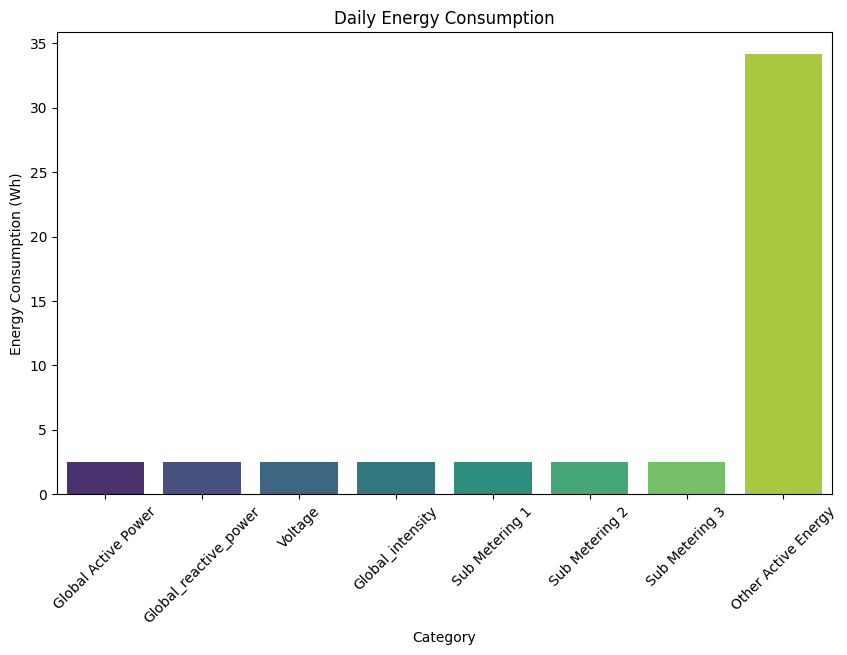

In [ ]:
plt.figure(figsize=(10, 6))
categories = ['Global Active Power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub Metering 1', 'Sub Metering 2', 'Sub Metering 3', 'Other Active Energy']
values = daily_consumption.iloc[0, 1:].values  # Ambil nilai dari baris pertama, kecuali kolom Date

sns.barplot(x=categories, y=values, palette='viridis')
plt.title('Daily Energy Consumption')
plt.ylabel('Energy Consumption (Wh)')
plt.xlabel('Category')
plt.xticks(rotation=45)
plt.show()

In [ ]:
# Menambahkan kolom 'Other_active_energy' ke dalam DataFrame
data['Other_active_energy'] = (
    data['Global_active_power'] * 1000 / 60
    - (data['Sub_metering_1'] + data['Sub_metering_2'] + data['Sub_metering_3'])
)

# Tampilkan DataFrame dengan kolom baru
print(data)

   Global_active_power  Global_reactive_power  Voltage  Global_intensity  \
0                 0.00                   0.00     0.00              0.00   
1                 0.25                   0.25     0.25              0.25   
2                 0.50                   0.50     0.50              0.50   
3                 0.75                   0.75     0.75              0.75   
4                 1.00                   1.00     1.00              1.00   

   Sub_metering_1  Sub_metering_2  Sub_metering_3            Datetime  \
0            0.00            0.00            0.00 2007-01-01 00:00:00   
1            0.25            0.25            0.25 2007-01-01 01:00:00   
2            0.50            0.50            0.50 2007-01-01 02:00:00   
3            0.75            0.75            0.75 2007-01-01 03:00:00   
4            1.00            1.00            1.00 2007-01-01 04:00:00   

         date  Other_active_energy  
0  2007-01-01             0.000000  
1  2007-01-01             3.41

### **Energy Usage Ratio (e.g., Kitchen vs Total Consumption)**

In [ ]:
data['kitchen_ratio'] = data['Sub_metering_1'] / (data['Global_active_power'] * 1000 / 60)
data['laundry_ratio'] = data['Sub_metering_2'] / (data['Global_active_power'] * 1000 / 60)
data['heating_ac_ratio'] = data['Sub_metering_3'] / (data['Global_active_power'] * 1000 / 60)

print(data['kitchen_ratio'])
print(data['laundry_ratio'])
print(data['heating_ac_ratio'])

0     NaN
1    0.06
2    0.06
3    0.06
4    0.06
Name: kitchen_ratio, dtype: float64
0     NaN
1    0.06
2    0.06
3    0.06
4    0.06
Name: laundry_ratio, dtype: float64
0     NaN
1    0.06
2    0.06
3    0.06
4    0.06
Name: heating_ac_ratio, dtype: float64


## **Correlation Analysis**

In [ ]:
print(data.columns)

Index(['Global_active_power', 'Global_reactive_power', 'Voltage',
       'Global_intensity', 'Sub_metering_1', 'Sub_metering_2',
       'Sub_metering_3', 'Datetime', 'date', 'Other_active_energy',
       'kitchen_ratio', 'laundry_ratio', 'heating_ac_ratio'],
      dtype='object')


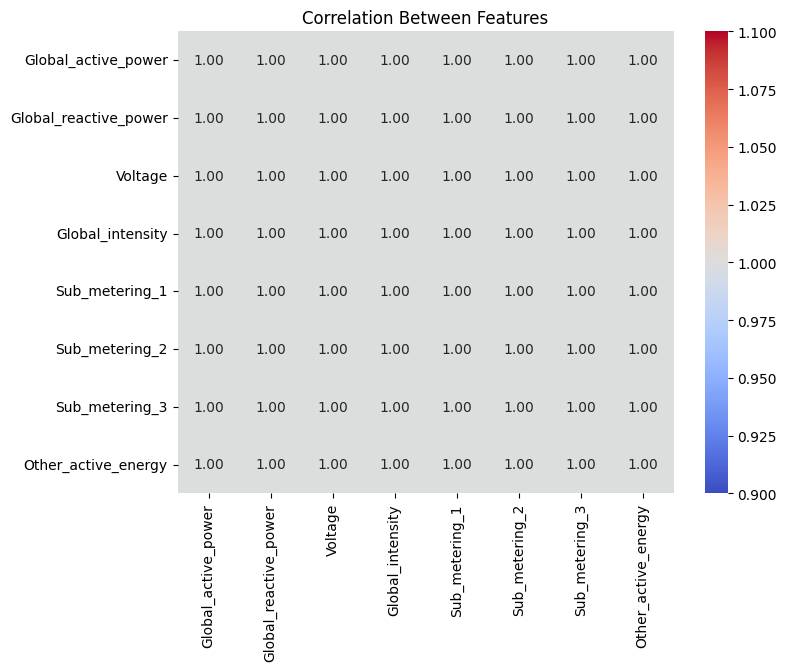

In [ ]:
correlation_matrix = data[['Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity',
                           'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3','Other_active_energy']].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Between Features')
plt.show()

## **Impact Analysis**

### **Analyzing Peak Hours (When is energy usage highest?)**

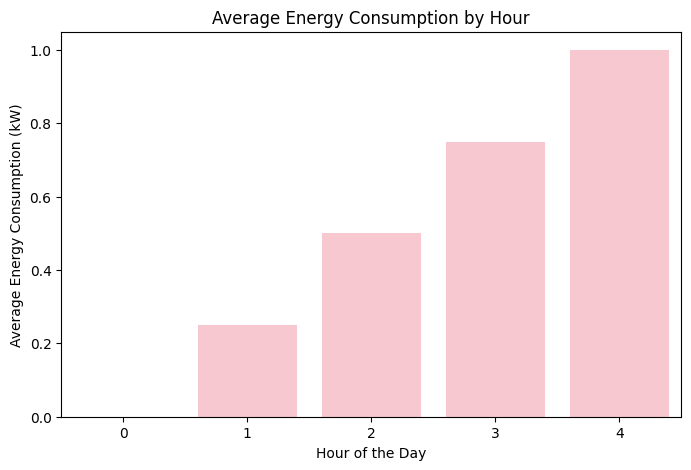

In [ ]:
data['hour'] = data['Datetime'].dt.hour
peak_hours = data.groupby('hour').agg({
    'Global_active_power': 'mean',
    'Other_active_energy': 'mean'
}).reset_index()

plt.figure(figsize=(8, 5))
sns.barplot(x='hour', y='Global_active_power', data=peak_hours, color='pink')
plt.title('Average Energy Consumption by Hour')
plt.xlabel('Hour of the Day')
plt.ylabel('Average Energy Consumption (kW)')
plt.show()

### **Energy Inefficiency by Area**

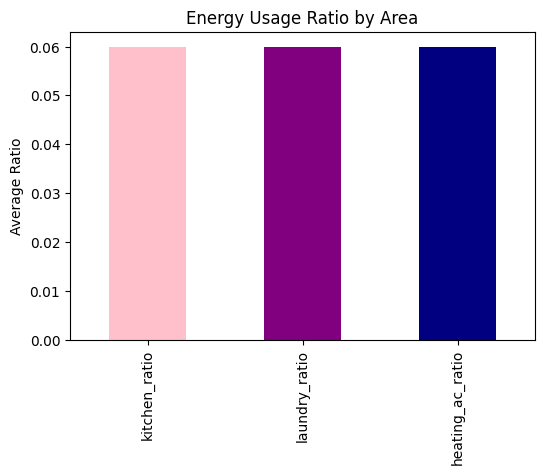

In [ ]:
inefficiency = data[['kitchen_ratio', 'laundry_ratio', 'heating_ac_ratio']].mean()
inefficiency.plot(kind='bar', figsize=(6, 4), color=['pink', 'purple', 'navy'], title='Energy Usage Ratio by Area')
plt.ylabel('Average Ratio')
plt.show()

# **Split Data**

In [ ]:
from sklearn.model_selection import train_test_split

# Misalkan kita ingin memprediksi 'Global_active_power' sebagai target
# dan menggunakan kolom lainnya sebagai fitur
X = loaded_data.drop(columns=['Global_active_power'])  # Fitur
y = loaded_data['Global_active_power']  # Target

# Membagi data menjadi set pelatihan dan set pengujian
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Menampilkan ukuran set pelatihan dan set pengujian
print(f"Ukuran set pelatihan: {X_train.shape[0]} baris")
print(f"Ukuran set pengujian: {X_test.shape[0]} baris")

Ukuran set pelatihan: 1639424 baris
Ukuran set pengujian: 409856 baris


In [ ]:
print(loaded_data.columns)

Index(['Global_active_power', 'Global_reactive_power', 'Voltage',
       'Global_intensity', 'Sub_metering_1', 'Sub_metering_2',
       'Sub_metering_3', 'Datetime'],
      dtype='object')


# **Model Building**

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, GRU, SimpleRNN, Dropout
from sklearn.metrics import mean_squared_error, mean_absolute_error
from keras.layers import Input
import numpy as np

# Pastikan data Anda sudah siap dalam bentuk yang sesuai
# Gunakan data X_train, X_test, y_train, y_test yang telah disiapkan

# Mengubah data menjadi bentuk 3D untuk input ke LSTM, GRU, dan RNN
X_train_3D = np.reshape(X_train.values, (X_train.shape[0], 1, X_train.shape[1]))
X_test_3D = np.reshape(X_test.values, (X_test.shape[0], 1, X_test.shape[1]))

In [ ]:
# Fungsi untuk preprocess data
def preprocess_data(X_train, X_test, has_timestamp=False):
    # Jika memiliki kolom waktu, proses timestamp
    if has_timestamp:
        # Konversi array ke DataFrame sementara jika bukan DataFrame
        if not isinstance(X_train, pd.DataFrame):
            X_train = pd.DataFrame(X_train, columns=["Datetime"] + [f"feature_{i}" for i in range(X_train.shape[1] - 1)])
            X_test = pd.DataFrame(X_test, columns=["Datetime"] + [f"feature_{i}" for i in range(X_test.shape[1] - 1)])

        # Proses timestamp
        X_train['Datetime'] = pd.to_datetime(X_train['Datetime'])
        X_train['Datetime'] = X_train['Datetime'].astype(int) / 10**9  # Ubah ke detik sejak epoch
        X_test['Datetime'] = pd.to_datetime(X_test['Datetime'])
        X_test['Datetime'] = X_test['Datetime'].astype(int) / 10**9

    # Jika input adalah DataFrame, hapus kolom non-numerik
    if isinstance(X_train, pd.DataFrame):
        X_train = X_train.select_dtypes(include=[np.number])
    if isinstance(X_test, pd.DataFrame):
        X_test = X_test.select_dtypes(include=[np.number])

    return X_train, X_test

In [ ]:
# Fungsi untuk membangun dan melatih model
def build_and_train_model(X_train, X_test, y_train, y_test, model_type="LSTM", timesteps=1, has_timestamp=False):
    # Pastikan X_train dan X_test berupa DataFrame sebelum preprocessing
    if not isinstance(X_train, pd.DataFrame):
        X_train = pd.DataFrame(X_train)
    if not isinstance(X_test, pd.DataFrame):
        X_test = pd.DataFrame(X_test)

    # Preprocessing data
    X_train, X_test = preprocess_data(X_train, X_test, has_timestamp=has_timestamp)

    # Konversi ke float32 setelah preprocessing
    X_train = np.array(X_train).astype(np.float32)
    X_test = np.array(X_test).astype(np.float32)
    y_train = np.array(y_train).astype(np.float32)
    y_test = np.array(y_test).astype(np.float32)

    # Mendefinisikan input shape
    input_shape = (timesteps, X_train.shape[1])

    # Membuat model
    model = Sequential()
    model.add(Input(shape=input_shape))
    if model_type == "LSTM":
        model.add(LSTM(50, activation='relu'))
    elif model_type == "GRU":
        model.add(GRU(50, activation='relu'))
    elif model_type == "RNN":
        model.add(SimpleRNN(50, activation='relu'))
    else:
        raise ValueError("Model type tidak valid. Pilih antara 'LSTM', 'GRU', atau 'RNN'.")

    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])

    # Reshape data
    X_train_reshaped = X_train.reshape((X_train.shape[0], timesteps, X_train.shape[1]))
    X_test_reshaped = X_test.reshape((X_test.shape[0], timesteps, X_test.shape[1]))

    # Melatih model
    history = model.fit(X_train_reshaped, y_train, validation_data=(X_test_reshaped, y_test), epochs=10, batch_size=32)

    # Prediksi
    predictions = model.predict(X_test_reshaped)

    return model, history, predictions

# **Train Model LSTM, GRU, dan RNN**

In [ ]:
# Pastikan X_train, X_test, y_train, dan y_test telah didefinisikan sebelumnya
print("\nModel LSTM")
lstm_model, lstm_history, lstm_predictions = build_and_train_model(X_train, X_test, y_train, y_test, model_type="LSTM", has_timestamp=True)

print("\nModel GRU")
gru_model, gru_history, gru_predictions = build_and_train_model(X_train, X_test, y_train, y_test, model_type="GRU", has_timestamp=True)

print("\nModel RNN")
rnn_model, rnn_history, rnn_predictions = build_and_train_model(X_train, X_test, y_train, y_test, model_type="RNN", has_timestamp=True)


Model LSTM
Epoch 1/10
51232/51232 ━━━━━━━━━━━━━━━━━━━━ 138s 3ms/step - loss: 2749523296256.0000 - mae: 120366.1797 - val_loss: 32997.8281 - val_mae: 181.5508
Epoch 2/10
51232/51232 ━━━━━━━━━━━━━━━━━━━━ 143s 3ms/step - loss: 3539620096.0000 - mae: 23452.6328 - val_loss: 516.7045 - val_mae: 22.5342
Epoch 3/10
51232/51232 ━━━━━━━━━━━━━━━━━━━━ 138s 3ms/step - loss: 2794446080.0000 - mae: 21193.1758 - val_loss: 10147403.0000 - val_mae: 3184.1548
Epoch 4/10
51232/51232 ━━━━━━━━━━━━━━━━━━━━ 135s 3ms/step - loss: 1998229376.0000 - mae: 16784.6973 - val_loss: 38168.7617 - val_mae: 195.2721
Epoch 5/10
51232/51232 ━━━━━━━━━━━━━━━━━━━━ 148s 3ms/step - loss: 1497037184.0000 - mae: 15211.0615 - val_loss: 41981497344.0000 - val_mae: 204807.3750
Epoch 6/10
51232/51232 ━━━━━━━━━━━━━━━━━━━━ 138s 3ms/step - loss: 1098211328.0000 - mae: 12792.8037 - val_loss: 1394514.6250 - val_mae: 1180.3964
Epoch 7/10
51232/51232 ━━━━━━━━━━━━━━━━━━━━ 139s 3ms/step - loss: 699595648.0000 - mae: 10138.0645 - val_loss: 31

# **Model Evaluation**

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Fungsi untuk evaluasi model
def evaluate_model(y_true, y_pred, model_name="Model"):
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print(f"\nEvaluasi {model_name}:")
    print(f"Mean Squared Error (MSE): {mse:.4f}")
    print(f"Mean Absolute Error (MAE): {mae:.4f}")
    print(f"R-squared (R²): {r2:.4f}")

# Evaluasi model LSTM
evaluate_model(y_test, lstm_predictions, model_name="LSTM")

# Evaluasi model GRU
evaluate_model(y_test, gru_predictions, model_name="GRU")

# Evaluasi model RNN
evaluate_model(y_test, rnn_predictions, model_name="RNN")


Evaluasi LSTM:
Mean Squared Error (MSE): 6.4965
Mean Absolute Error (MAE): 2.4988
R-squared (R²): -118.8300

Evaluasi GRU:
Mean Squared Error (MSE): 0.0020
Mean Absolute Error (MAE): 0.0116
R-squared (R²): 0.9632

Evaluasi RNN:
Mean Squared Error (MSE): 0.0020
Mean Absolute Error (MAE): 0.0117
R-squared (R²): 0.9629


# **Visualization of Training Results**

In [ ]:
# Visualisasi hasil pelatihan
import matplotlib.pyplot as plt

def plot_training_history(history, model_type):
    plt.figure(figsize=(12, 6))

    # Plot loss
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'{model_type} Model Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    # Plot MAE
    plt.subplot(1, 2, 2)
    plt.plot(history.history['mae'], label='Train MAE')
    plt.plot(history.history['val_mae'], label='Validation MAE')
    plt.title(f'{model_type} Model MAE')
    plt.xlabel('Epochs')
    plt.ylabel('MAE')
    plt.legend()

    plt.tight_layout()
    plt.show()

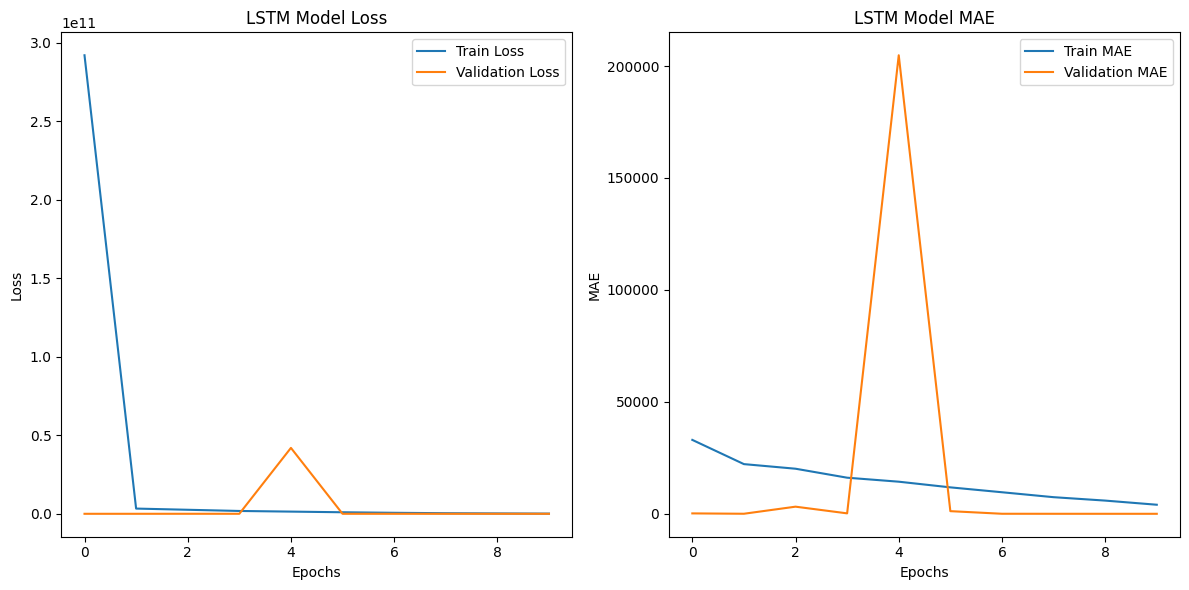

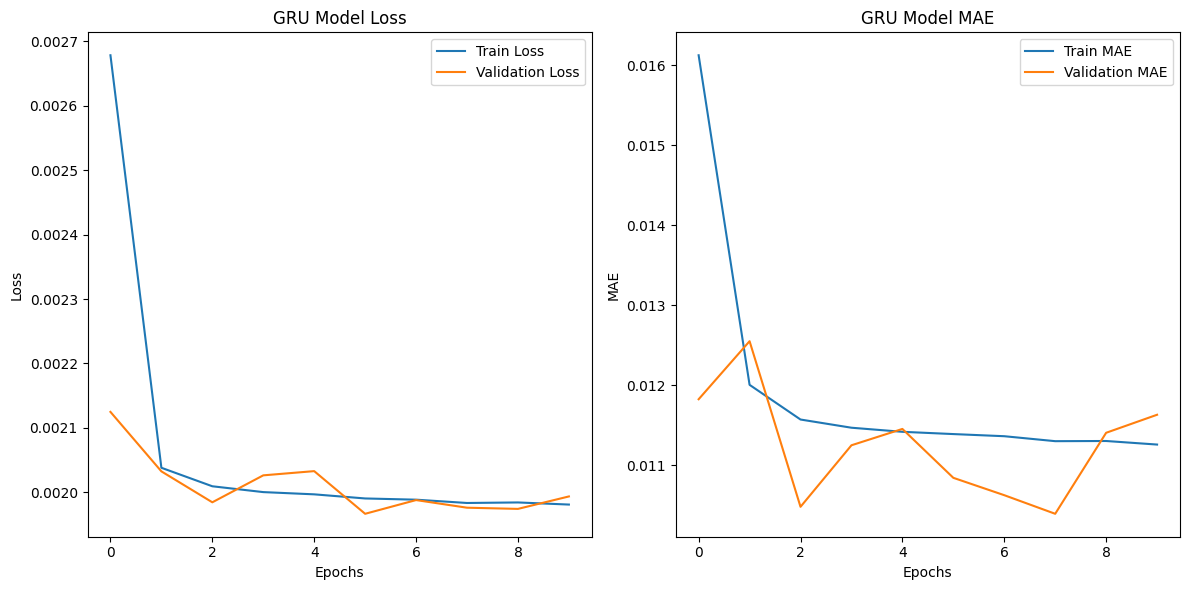

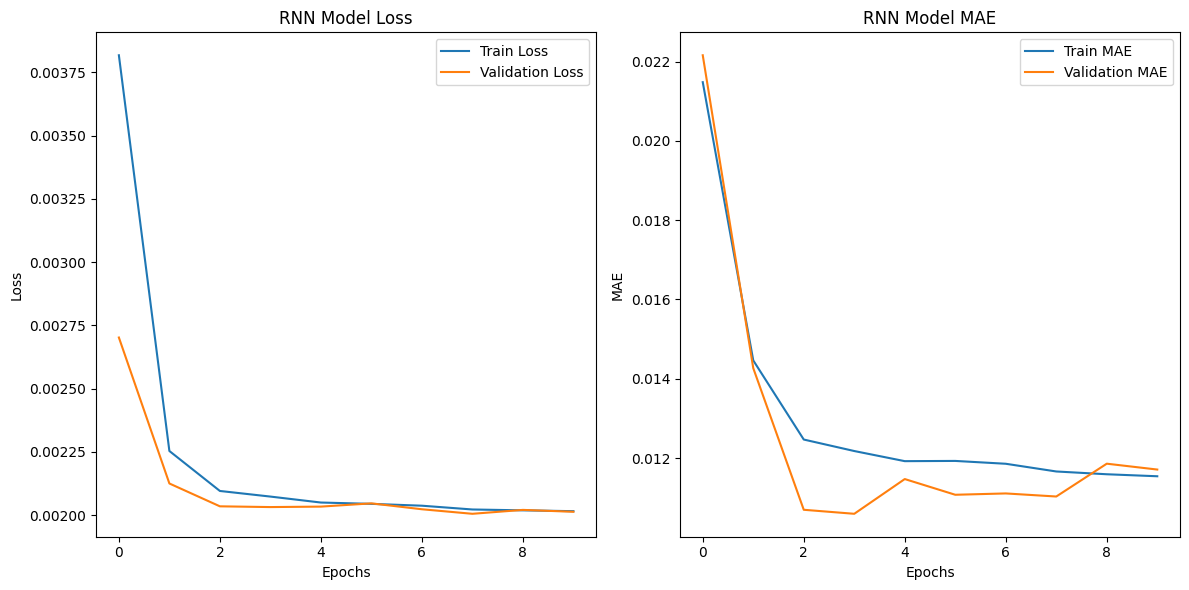

In [ ]:
# Plot training history untuk masing-masing model
plot_training_history(lstm_history, "LSTM")
plot_training_history(gru_history, "GRU")
plot_training_history(rnn_history, "RNN")

# **Model Prediction**

In [ ]:
# Menampilkan beberapa prediksi
print("\nBeberapa Prediksi LSTM:")
print(lstm_predictions[:10].flatten())
print("\nBeberapa Prediksi GRU:")
print(gru_predictions[:10].flatten())
print("\nBeberapa Prediksi RNN:")
print(rnn_predictions[:10].flatten())


Beberapa Prediksi LSTM:
[2.5168715 2.7668715 3.0168715 2.7668715 2.5168715 2.5168715 2.7668715
 2.5168715 2.7668715 2.5168715]

Beberapa Prediksi GRU:
[0.4392128  0.08735698 0.17807381 0.06139431 0.39058048 0.0688695
 0.03722635 0.64707327 0.11320715 0.5222551 ]

Beberapa Prediksi RNN:
[0.44653404 0.08702053 0.17651013 0.05894722 0.39572287 0.070346
 0.03796346 0.67075    0.11526291 0.52608913]
